# Forced Simple Harmonic Oscillator System Identification (Unknown Forcing Frequency) 

In [241]:
# import all the necessary libraries
import pysindy as ps
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

In [322]:
def simple_harmonic_oscillator(t, x, zeta=0.1, omega_n = 1, Fhat=2, omega=1.5):
    return [x[1], 
           -2*zeta*omega_n*x[1] - omega_n ** 2 * x[0] + Fhat * np.sin(x[2]),
           omega
           ]

In [323]:
# generate the data for testing
start = 0
end = 100
step = 0.01
t_span = [start, end]
x0 = [0.3, 0.6, 0]
sol = solve_ivp(simple_harmonic_oscillator, t_span, x0, rtol=1e-6, atol=1e-9, dense_output=True)
t = np.arange(start, end+step/10, step)
x = sol.sol(t).T
n_points = len(t)

x_train = x[int(n_points*0.7):]
t_train = t[int(n_points*0.7):]


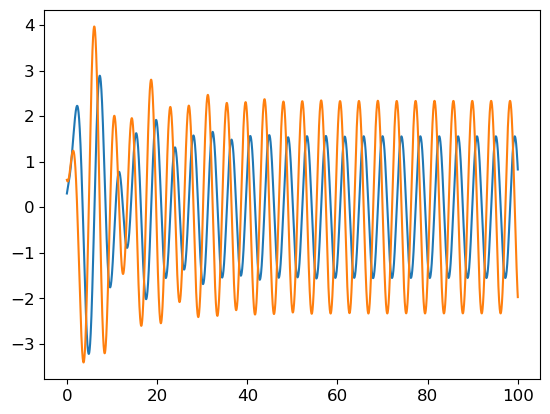

In [332]:
plt.plot(t,x[:,:-1])

In [324]:
print(x_train)

[[ 1.55766216e+00  2.00321271e-02  1.05000000e+02]
 [ 1.55768733e+00 -1.49960633e-02  1.05015000e+02]
 [ 1.55736223e+00 -5.00206375e-02  1.05030000e+02]
 ...
 [ 8.66661625e-01 -1.93791607e+00  1.49970000e+02]
 [ 8.47185687e-01 -1.95719869e+00  1.49985000e+02]
 [ 8.27519120e-01 -1.97604094e+00  1.50000000e+02]]


In [325]:
# # The feature names of the columns of y
# feature_names = ['x1', 'x2', 'omega t']

# # Which feature library to use
# poly_lib = ps.PolynomialLibrary(degree=3)
# fourier_lib = ps.FourierLibrary()

# inputs_temp = np.tile([0, 1, 2], 2)
# inputs_per_library = np.reshape(inputs_temp, (2,3))

# inputs_per_library[0,2] = 1
# inputs_per_library[1,0] = 2
# inputs_per_library[1,1] = 2
# inputs_per_library[1,2] = 2
# print(inputs_per_library)

# generalized_library = ps.GeneralizedLibrary(
#     [poly_lib, fourier_lib],
# inputs_per_library = inputs_per_library)

# # Differentiation method
# differentiation_method = ps.FiniteDifference(order=2)


# # Optimizer
# opt = ps.STLSQ(threshold=0.1)
# # opt = ps.SR3(threshold=0.1,thresholder="L1")
# # opt = ps.FROLS(max_iter=5,alpha=0.5)
# # opt = ps.SSR()

# # Building the model
# model=ps.SINDy(differentiation_method=differentiation_method,
#                feature_library = generalized_library,
#                feature_names=feature_names, 
#               optimizer=opt)


# # Fitting the model to the training data
# model.fit(x_train,t=t_train)
# # model.fit(x,t=t)

# # Print the model
# model.print()

# model.get_feature_names()

In [326]:
# def calculate_frequency(signal, time):
#     # Perform FFT
#     n = len(signal)  # Length of the signal
#     sample_rate = n / (time[-1] - time[0])  # Calculate the sample rate
#     frequencies = np.fft.fftfreq(n, d=1/sample_rate)  # Calculate the frequencies
#     signal_fft = np.fft.fft(signal)  # Compute the FFT

#     # Find the index of the peak frequency
#     peak_index = np.argmax(np.abs(signal_fft))

#     # Get the peak frequency
#     peak_frequency = frequencies[peak_index]

#     return abs(peak_frequency)

# signal = x_train[:,0]
# time = t_train

# frequency = calculate_frequency(signal, time)
# print("Peak Frequency:", frequency)

In [327]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import welch

# # Generate a sample signal
# fs = 100  # Sample rate (Hz)
# time = t_train  # Time vector
# signal = x_train[:,0]  # Signal

# # Compute the power spectral density
# frequencies, psd = welch(signal, fs, nperseg=2**9)

# # Find the peak value and its corresponding frequency
# peak_idx = np.argmax(psd)
# peak_freq = frequencies[peak_idx]
# peak_psd = psd[peak_idx]

# # Plot the PSD
# plt.figure()
# plt.semilogy(frequencies, psd)
# plt.plot(peak_freq, peak_psd, 'ro', label='Peak PSD')
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Power Spectral Density')
# plt.legend()
# plt.grid(True)
# plt.show()

# print("Peak Frequency:", peak_freq)
# print("Peak PSD:", peak_psd)
# print('omega:', (2*np.pi)*peak_freq)

In [328]:
# frequency calculation using zero crossing method

def compute_frequency(signal, sample_rate):
    '''Compute the frequency of a signal'''
    zero_crossings = np.where(np.diff(np.sign(signal)))[0]
    periods = np.diff(zero_crossings) / sample_rate
    positive_zero_crossings = zero_crossings[signal[zero_crossings] > 0]
    frequency = 0.5 / np.mean(periods)
    return frequency

# Example usage
signal = x_train[:,0]
sample_rate = 100  # Sample rate in Hz

frequency = compute_frequency(signal, sample_rate)
print("Estimated frequency:", frequency, "Hz")
omega = 2*np.pi*frequency
print("Omega:", omega)

Estimated frequency: 0.23879500367376927 Hz
Omega: 1.5003932585109223


In [329]:
# import numpy as np
# from scipy.signal import find_peaks

# def find_period(x, Ts):
#     # Compute autocorrelation and lags
#     autocorr, lags = np.correlate(x, x, mode='full'), np.arange(-(len(x)-1), len(x))
    
#     # Find peaks in autocorrelation
#     peaks, _ = find_peaks(autocorr)
    
#     # Calculate the time period
#     difference = np.diff(peaks)
#     T = np.mean(difference[2:-2]) * Ts
    
#     return T, autocorr, lags

# signal = x_train[:,0]
# time = t_train

# T, autocorr, lags = find_period(signal, 0.01)
# print("Period:", T)

# f = 1/T
# print(f)

# omega = 2*np.pi/T

# print(omega)

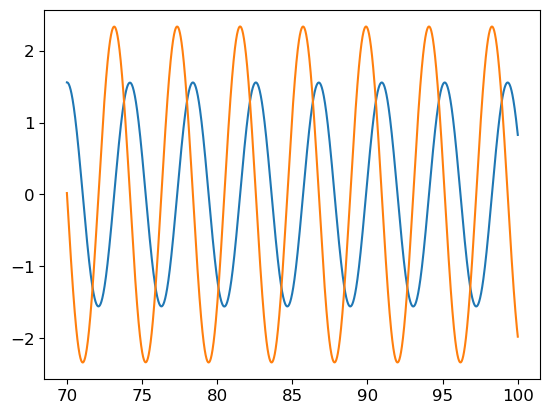

In [330]:
plt.plot(t_train, x_train[:,:2])
# plt.plot(t,x[:,0])

In [398]:
# The feature names of the columns of y
feature_names = ['x1', 'x2', 'omega t']

# Which feature library to use
poly_lib = ps.PolynomialLibrary(degree=3)
fourier_lib = ps.FourierLibrary(3)

inputs_temp = np.tile([0, 1, 2], 2)
inputs_per_library = np.reshape(inputs_temp, (2,3))

inputs_per_library[0,0] = 0
inputs_per_library[0,1] = 1
inputs_per_library[0,2] = 1
inputs_per_library[1,0] = 2
inputs_per_library[1,1] = 2
inputs_per_library[1,2] = 2

# print(inputs_per_library)

generalized_library = ps.GeneralizedLibrary(
    [poly_lib, fourier_lib],
    inputs_per_library = inputs_per_library)

# Differentiation method
differentiation_method = ps.FiniteDifference(order=2)


# Optimizer
opt = ps.STLSQ(threshold=0.1)
# opt = ps.SR3(threshold=0.5,thresholder="L0")
# opt = ps.FROLS(max_iter=5,alpha=0.5)
# opt = ps.SSR()


# custom_lib = poly_lib + fourier_lib
# Building the model
model=ps.SINDy(differentiation_method=differentiation_method,
               feature_library = generalized_library,
               feature_names=feature_names, 
              optimizer=opt)


## Last 50 seconds used for identification

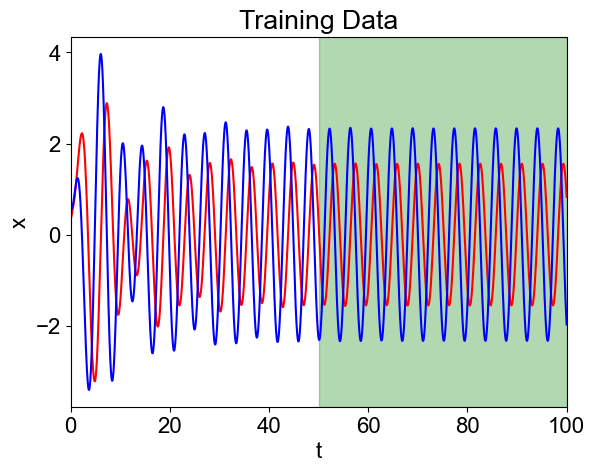

(x1)' = 1.000 x2
(x2)' = -2.250 x1
(omega t)' = 1.500 1


In [399]:

x_train = x[int(n_points*0.5):,:-1]
t_train = t[int(n_points*0.5):]
x_train = np.hstack((x_train, omega * t_train.reshape((x_train.shape[0],1))))

# plot the data
plt.rcdefaults()
plt.rcParams.update({'font.size': 16})

plt.rcParams['font.family'] = 'Sans-Serif'
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots()
ax.plot(t, x[:,0],'r',linewidth=1.5)
ax.plot(t, x[:,1],'blue',linewidth=1.5)
ax.axvspan(0.5*(t[-1]-t[0]),1*(t[-1]-t[0]), alpha=0.3, color='green')
plt.xlim((0,t[-1]))
plt.xlabel('t')
plt.ylabel('x')
plt.title("Training Data")
# Show the plot
plt.savefig('training_data_50sec_SHO.pdf', format='pdf', dpi=600)
plt.show()


# Fitting the model to the training data
model.fit(x_train,t=t_train)
# model.fit(x,t=t)

# Print the model
model.print()

# model.get_feature_names()

In [394]:
# Simulate the identified system 
sim = model.simulate(x0,t=t)

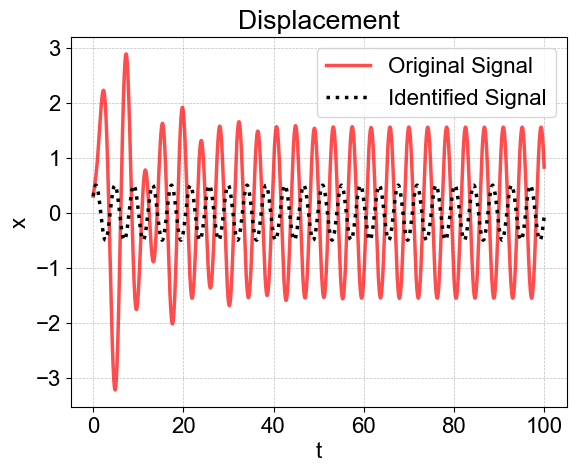

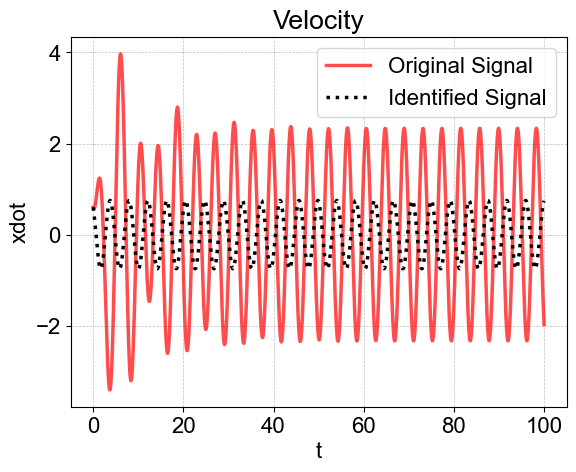

In [395]:
# plot the solution

plt.rcParams.update({'font.size': 16})

# displacement
plt.plot(t,x[:,0],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,0],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('disp_sho_f_50sec.pdf', format='pdf', dpi=300)
plt.title('Displacement')
plt.show()


# velocity
plt.plot(t,x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,1],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("xdot")
plt.legend(loc='upper right')
plt.title("Velocity")
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('vel_sho_f_50sec.pdf', format='pdf', dpi=300)
plt.show()

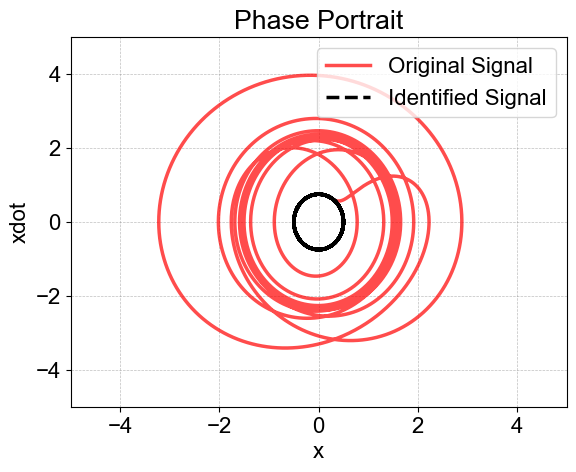

In [396]:
# Phase Portrait
plt.plot(x[:,0],x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(sim[:,0],sim[:,1],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("x")
plt.ylabel("xdot")
plt.xlim((-5,5))
plt.ylim((-5,5))
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.title('Phase Portrait')
plt.savefig('pp_sho_f_50sec.pdf', format='pdf', dpi=300)
plt.show()

In [397]:
R2 = r2_score(x[:,0],sim[:,0])
MSE = mean_squared_error(x[:,0],sim[:,0])

print(f"R2 score: {R2}")
print(f"Mean Squared Error: {MSE}")

R2 score: -0.5941939188970426
Mean Squared Error: 2.274949602884035
